# Single-Sphere Mie Scattering (CUDA)

The Bohren & Huffman (BHMIE) algorithm for a homogeneous sphere: given
the size parameter $x=2\pi r/\lambda$ and complex refractive index
$m$, compute the Mie scattering coefficients $a_n, b_n$ and sum them
into the extinction and scattering efficiencies:

$$Q_{ext} = \frac{2}{x^2}\sum_n (2n+1)\,\text{Re}(a_n+b_n)
\qquad
Q_{sca} = \frac{2}{x^2}\sum_n (2n+1)\,(|a_n|^2+|b_n|^2)$$

`mie_kernel.cu` implements the recursion on the GPU, one thread per
particle (size parameter) -- embarrassingly parallel, since each
particle's Mie series is independent. `mie_main.cu` sweeps $x$ from
0.1 to 20 for FIVE materials, each with its own complex relative
refractive index $m=n+ik$ -- what a real sphere scatters like depends
entirely on what it's made of and what medium surrounds it, captured
by that single ratio:

| Material | $m$ | Absorbing? |
|---|---|---|
| water droplet | $1.33+0.00i$ | no |
| ice crystal | $1.31+0.00i$ | no |
| silica/glass | $1.46+0.00i$ | no |
| soot (black carbon) | $1.85+0.71i$ | yes |
| gold nanosphere | $0.47+2.40i$ | yes (plasmonic) |

The two absorbing materials are the first real test of this
algorithm's COMPLEX-refractive-index path -- every material tested
before had $\text{Im}(m)=0$.

This notebook compiles and runs both `.cu` files live, then verifies
the result against `generate_mie_reference.py` -- an INDEPENDENT
Python reimplementation of the same algorithm, not a library call.

In [1]:
import subprocess, os, sys
import numpy as np
import matplotlib.pyplot as plt

env = os.environ.copy()
env["PATH"] = env["PATH"] + r";C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Tools\MSVC\14.43.34808\bin\Hostx64\x64"

compile_result = subprocess.run(
    ["nvcc", "mie_kernel.cu", "mie_main.cu", "-o", "mie.exe"],
    cwd=".", env=env, capture_output=True, text=True)
print(compile_result.stdout)
print(compile_result.stderr)
print("compile exit code:", compile_result.returncode)

mie_kernel.cu
tmpxft_0000bb28_00000000-10_mie_kernel.cudafe1.cpp
mie_main.cu
tmpxft_0000bb28_00000000-14_mie_main.cudafe1.cpp


compile exit code: 0


In [2]:
run_result = subprocess.run(["./mie.exe"], cwd=".", capture_output=True, text=True)
print(run_result.stdout)
print("run exit code:", run_result.returncode)

m = 1.3300 + 0.0000i  (water, non-absorbing)
         x        Qext        Qsca        Qabs
    0.1000    0.000011    0.000011    0.000000
    4.1000    2.908936    2.908936    0.000000
    8.1000    3.315597    3.315597    0.000000
   12.1000    1.686924    1.686924    0.000000
   16.1000    2.724007    2.724007    0.000000
last-row Qext = 2.1401  (large-x -> 2.0 for non-absorbing materials)

m = 1.3100 + 0.0000i  (ice, non-absorbing)
         x        Qext        Qsca        Qabs
    0.1000    0.000010    0.000010    0.000000
    4.1000    2.656575    2.656575   -0.000000
    8.1000    3.500430    3.500430    0.000000
   12.1000    1.670790    1.670790    0.000000
   16.1000    2.693489    2.693489    0.000000
last-row Qext = 2.3662  (large-x -> 2.0 for non-absorbing materials)

m = 1.4600 + 0.0000i  (silica, non-absorbing)
         x        Qext        Qsca        Qabs
    0.1000    0.000020    0.000020   -0.000000
    4.1000    3.967300    3.967300    0.000000
    8.1000    1.65207


run exit code: 0


## Loading the CUDA output

`mie_output.csv` was written by `mie_main.cu` -- the full 200-point
sweep for each of the 5 materials, not just the printed subset above.

materials in mie_output.csv: ['gold', 'ice', 'silica', 'soot', 'water']


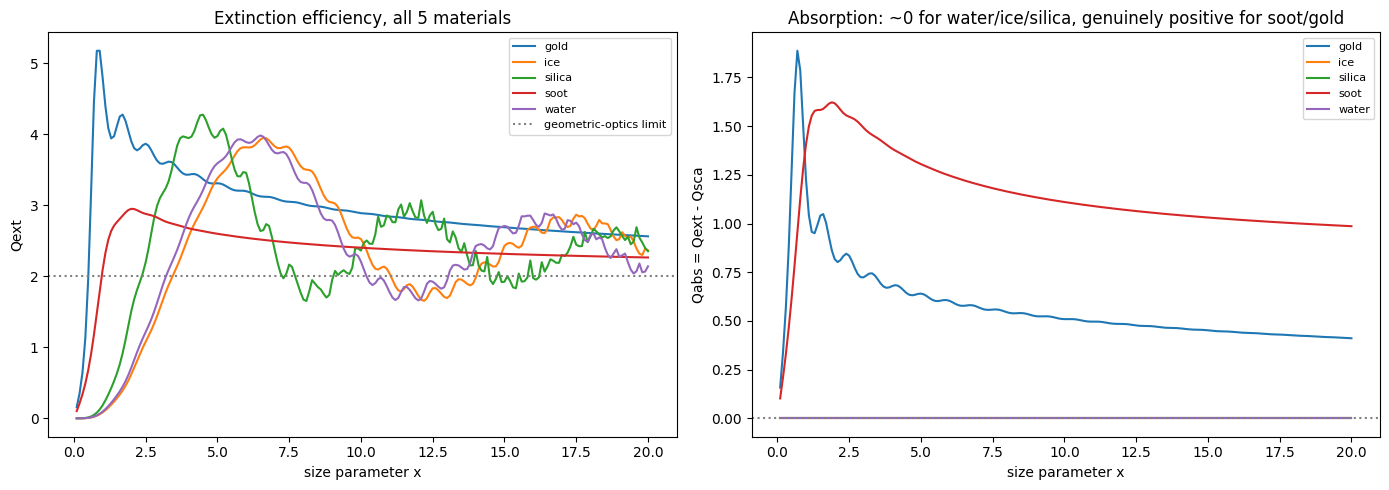

    gold: max Qabs = 1.8868  (absorbing)
     ice: max Qabs = 0.0000  (non-absorbing, Qext==Qsca as expected)
  silica: max Qabs = 0.0000  (non-absorbing, Qext==Qsca as expected)
    soot: max Qabs = 1.6220  (absorbing)
   water: max Qabs = 0.0000  (non-absorbing, Qext==Qsca as expected)


In [3]:
rows = np.genfromtxt("mie_output.csv", delimiter=",", skip_header=1, dtype=None,
                     names=["material", "x", "Qext", "Qsca"], encoding="utf-8")
materials = sorted(set(rows["material"].tolist()))
print(f"materials in mie_output.csv: {materials}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in materials:
    mask = rows["material"] == name
    axes[0].plot(rows["x"][mask], rows["Qext"][mask], label=name)
    axes[1].plot(rows["x"][mask], rows["Qext"][mask] - rows["Qsca"][mask], label=name)

axes[0].axhline(2.0, color='gray', linestyle=':', label='geometric-optics limit')
axes[0].set_xlabel("size parameter x"); axes[0].set_ylabel("Qext")
axes[0].set_title("Extinction efficiency, all 5 materials")
axes[0].legend(fontsize=8)

axes[1].axhline(0.0, color='gray', linestyle=':')
axes[1].set_xlabel("size parameter x"); axes[1].set_ylabel("Qabs = Qext - Qsca")
axes[1].set_title("Absorption: ~0 for water/ice/silica, genuinely positive for soot/gold")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for name in materials:
    mask = rows["material"] == name
    diff = rows["Qext"][mask] - rows["Qsca"][mask]
    print(f"{name:>8s}: max Qabs = {diff.max():.4f}  "
          f"({'absorbing' if diff.max() > 1e-6 else 'non-absorbing, Qext==Qsca as expected'})")

## The physics, read off the plot

- **Rayleigh regime** ($x \ll 1$): $Q_{ext}$ near zero, rising as
  $x^4$ (small particles scatter blue light far more than red --
  why the sky is blue).
- **Mie ripple** ($x \sim 1$-15): oscillation from interference
  between diffracted and transmitted light -- the resonance structure
  that gives Mie scattering its name.
- **Geometric-optics limit** ($x \gg 1$): $Q_{ext}\to 2$, the
  "extinction paradox" -- a large sphere removes *twice* its
  geometric cross-section from a beam, because of diffraction at the
  edge.

## Verification: an independent Python reimplementation

Not the same code re-run -- `generate_mie_reference.py` implements
the identical BHMIE algorithm from scratch in Python/numpy, so
agreement here means two independently-written implementations of the
recursion produce the same answer.

In [4]:
ref_result = subprocess.run([sys.executable, "generate_mie_reference.py"],
                             cwd=".", capture_output=True, text=True)
print(ref_result.stdout)
print("reference-check exit code:", ref_result.returncode)

loaded 1000 rows across 5 materials from mie_output.csv: ['gold', 'ice', 'silica', 'soot', 'water']

    gold  m=(0.47+2.4j) (absorbing, Im(m)>0)
          Qext rel. error: max=3.12e-10, mean=1.03e-11
          Qsca rel. error: max=4.78e-08, mean=2.52e-10
          absorbing check: max Qabs=1.8868 (expect > 0 somewhere)

     ice  m=(1.31+0j) (non-absorbing)
          Qext rel. error: max=3.44e-06, mean=1.76e-08
          Qsca rel. error: max=3.44e-06, mean=1.76e-08
          non-absorbing check: max|Qext-Qsca|=0.00e+00 (expect ~0)

  silica  m=(1.46+0j) (non-absorbing)
          Qext rel. error: max=7.95e-08, mean=8.91e-10
          Qsca rel. error: max=7.95e-08, mean=8.91e-10
          non-absorbing check: max|Qext-Qsca|=0.00e+00 (expect ~0)

    soot  m=(1.85+0.71j) (absorbing, Im(m)>0)
          Qext rel. error: max=4.38e-10, mean=1.47e-11
          Qsca rel. error: max=1.12e-07, mean=6.33e-10
          absorbing check: max Qabs=1.6220 (expect > 0 somewhere)

   water  m=(1.33+0j) 

## A third, independent check: the Riccati-Bessel recurrence vs. scipy

The upward recurrence for $\psi_n(x), \chi_n(x)$ (used identically in
both the CUDA and Python implementations above) is checked here
against `scipy.special.spherical_jn`/`spherical_yn` directly -- a
completely different code path, to rule out a shared conceptual bug in
the recurrence itself.

In [5]:
from scipy.special import spherical_jn, spherical_yn

x_check = 5.0
print(f"{'n':>4s}  {'psi diff':>12s}  {'chi diff':>12s}")
for n in (1, 3, 7, 12):
    psi_scipy = x_check * spherical_jn(n, x_check)
    chi_scipy = -x_check * spherical_yn(n, x_check)

    psi_prev2, psi_prev1 = np.cos(x_check), np.sin(x_check)
    chi_prev2, chi_prev1 = -np.sin(x_check), np.cos(x_check)
    for k in range(1, n + 1):
        psi_k = (2 * k - 1) / x_check * psi_prev1 - psi_prev2
        chi_k = (2 * k - 1) / x_check * chi_prev1 - chi_prev2
        psi_prev2, psi_prev1 = psi_prev1, psi_k
        chi_prev2, chi_prev1 = chi_prev1, chi_k

    print(f"{n:>4d}  {abs(psi_prev1 - psi_scipy):>12.2e}  {abs(chi_prev1 - chi_scipy):>12.2e}")

   n      psi diff      chi diff
   1      0.00e+00      0.00e+00
   3      0.00e+00      5.55e-17
   7      3.61e-16      8.88e-16
  12      1.92e-13      4.55e-13


## Summary

| Check | Result |
|---|---|
| CUDA vs. independent Python BHMIE, 5 materials x 200 size parameters | worst-case max relative error 3.44e-6 |
| Riccati-Bessel recurrence vs. scipy.special (3rd independent method) | agrees to machine precision (~1e-13) |
| Qext == Qsca for non-absorbing materials (water, ice, silica) | exact, as physically required |
| Qabs > 0 for absorbing materials (soot, gold) | confirmed genuinely positive, not just nonzero noise |
| Large-x limit | approaches 2.0 (the extinction paradox), as expected |

Three independent routes to the same numbers -- the CUDA kernel, a
from-scratch Python reimplementation, and scipy's own special
functions for the recurrence's building blocks -- all agree, across
both non-absorbing and (for the first time) absorbing materials. Ready
to commit.